# Computer Exercise 5.5 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 5.5 Gaussian Quadrature — *노드를 자유롭게 두면 차수가 두 배가 된다*
> **풀이 일자**: Day 21
> **언어**: Python 3 (NumPy / Matplotlib / Pandas)


## 1. 문제 (원문)

> **1.** Construct the **$n$-point Gauss–Legendre rule** on $[-1, 1]$ for $n = 2, 3, \ldots, 10$ by
> computing the roots $\{x_k\}_{k=1}^{n}$ of the Legendre polynomial $P_n(x)$ and the corresponding
> weights
> $$
> w_k \;=\; \frac{2}{(1 - x_k^2)\,[P_n'(x_k)]^2}.
> $$
> Verify the **degree of exactness $2n - 1$** by integrating the monomials $x^0, x^1, \ldots, x^{2n}$
> and showing the error is at machine precision for degrees $\leq 2n - 1$ and *jumps* at degree $2n$.
> Then apply your routine on $[a, b]$ (via affine change of variables) to
> $$
> \int_0^1 e^x\,dx = e - 1, \qquad
> \int_0^{\pi/2}\sin x\,dx = 1, \qquad
> \int_0^1 \tfrac{1}{1 + x^2}\,dx = \tfrac{\pi}{4},
> $$
> for $n = 2, 3, \ldots, 8$. Tabulate errors.

### 한국어 풀이용 정리
- 핵심 한 줄: **노드 $x_k$ 와 가중치 $w_k$ 를 *둘 다* 자유 변수로 두면, $n$ 점으로 *$2n - 1$ 차* 다항식을 정확히 적분**한다.
- Newton–Cotes 계열은 노드를 *균등하게* 고정 — 자유도 $n$ (가중치만) → 최대 차수 $n - 1$ (Simpson 처럼 짝수 $n$ 일 때 $+1$ 보너스). Gauss 는 자유도 $2n$ → 차수 $2n - 1$.
- 노드 = Legendre 다항식 $P_n$ 의 영점, 가중치 = 폐형식 공식.
- 임의 구간 $[a, b]$ 은 $x = \tfrac{b - a}{2} t + \tfrac{a + b}{2}$ 의 *아핀 변환* 으로 $[-1, 1]$ 로 옮긴다 — Jacobian 은 $(b - a)/2$.


## 2. 수학적 배경

### 2.1 직교다항식 한 줄
$[-1, 1]$ 위에서 *가중함수* $w(x) \equiv 1$ 에 대해 내적

$$
\langle f, g \rangle \;=\; \int_{-1}^{1} f(x)\, g(x)\, dx
$$

를 직교화하면 **Legendre 다항식** $\{P_0, P_1, P_2, \ldots\}$ 이 나온다. Bonnet 점화식

$$
(n + 1)\, P_{n + 1}(x) \;=\; (2n + 1)\, x\, P_n(x) \;-\; n\, P_{n - 1}(x), \qquad P_0 = 1,\ P_1 = x,
$$

으로 *수치적으로 안정* 하게 생성. $P_n$ 의 영점은 모두 $(-1, 1)$ 내부의 *단순* 영점, 그리고 *대칭*.

### 2.2 Gauss 정리 (핵심)
$P_n(x_k) = 0$ 인 노드와 가중치

$$
\boxed{\;w_k \;=\; \frac{2}{(1 - x_k^2)\,[P_n'(x_k)]^2}\;}
$$

를 잡으면, *모든* $f \in \mathbb{P}_{2n - 1}$ 에 대해

$$
\int_{-1}^{1} f(x)\, dx \;=\; \sum_{k = 1}^{n} w_k\, f(x_k)
$$

가 **정확**. 자유도 셈은 노드 $n$ 개 + 가중치 $n$ 개 = $2n$ 개 → $2n$ 차 다항식 $\{1, x, \ldots, x^{2n - 1}\}$ 의 *모멘트 매칭* 으로 결정.

### 2.3 오차 표현
$f \in C^{2n}[-1, 1]$ 이면

$$
E_n[f] \;=\; \int_{-1}^{1} f - \sum_{k} w_k f(x_k) \;=\; \frac{2^{2n + 1}\, (n!)^4}{(2n + 1)\,[(2n)!]^3}\, f^{(2n)}(\xi), \qquad \xi \in (-1, 1).
$$

핵심: 오차 $\propto f^{(2n)}$ — *부드러우면 $n$ 두 배가 자릿수 두 배 이상*. Romberg 의 *기하급수적* 차수 사다리보다도 *공격적*.

### 2.4 아핀 변환
$[a, b]$ 로 가려면

$$
\int_a^b g(x)\, dx \;=\; \frac{b - a}{2}\, \int_{-1}^{1} g\!\left(\frac{b - a}{2}\, t + \frac{a + b}{2}\right) dt.
$$

따라서 $x_k^{[a, b]} = \tfrac{b - a}{2}\, x_k + \tfrac{a + b}{2}$, $w_k^{[a, b]} = \tfrac{b - a}{2}\, w_k$.


## 3. 풀이 흐름

1. `legendre_value_and_deriv(n, x)` — Bonnet 점화로 $P_n$ 과 $P_n'$ 을 동시 평가.
2. `gauss_legendre_my(n)` — $P_n$ 의 영점을 *Newton 반복* 으로 구한다. 초기값은 Chebyshev 영점 $\cos\!\bigl(\tfrac{(k - 1/4)\pi}{n + 1/2}\bigr)$ — 점근적으로 *매우 가까움*. 가중치는 폐형식.
3. NumPy 의 `np.polynomial.legendre.leggauss(n)` 과 비교 — 내 구현의 신뢰성 확인.
4. **차수 정확성 (degree of exactness)** 검증: $n = 2, \ldots, 6$ 마다, 정확값 $\int_{-1}^{1} x^k\, dx$ 와 Gauss 적분의 차이를 $k = 0, 1, \ldots, 2n + 2$ 에 대해 표로. $k \leq 2n - 1$ 에서는 *$\sim 10^{-16}$*, $k = 2n$ 에서 *유한 값*.
5. 세 부드러운 적분 ($e^x$, $\sin$, $1/(1 + x^2)$) 에 아핀 변환을 적용, $n = 2, \ldots, 8$ 에서 절대오차표.
6. *그림*: 같은 함수평가 비용 $N_f$ 에서 Gauss vs 합성 Simpson 의 오차 곡선 — Gauss 가 *직선이 아니라 곡선* 이라는 점.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.6e}")
np.set_printoptions(linewidth=120, precision=12)

def legendre_value_and_deriv(n, x):
    """Bonnet recurrence: returns (P_n(x), P_n'(x))."""
    if n == 0:
        return np.ones_like(x), np.zeros_like(x)
    Pm1 = np.ones_like(x)
    P   = x.copy()
    for k in range(1, n):
        Pp1 = ((2 * k + 1) * x * P - k * Pm1) / (k + 1)
        Pm1, P = P, Pp1
    dP = n * (x * P - Pm1) / (x ** 2 - 1)
    return P, dP

def gauss_legendre_my(n, tol=1e-15, maxit=50):
    """Newton iteration on Chebyshev seeds for roots of P_n; closed-form weights."""
    k = np.arange(1, n + 1, dtype=float)
    x = np.cos(np.pi * (k - 0.25) / (n + 0.5))
    for _ in range(maxit):
        P, dP = legendre_value_and_deriv(n, x)
        dx = -P / dP
        x = x + dx
        if np.max(np.abs(dx)) < tol:
            break
    _, dP = legendre_value_and_deriv(n, x)
    w = 2.0 / ((1.0 - x ** 2) * dP ** 2)
    order = np.argsort(x)
    return x[order], w[order]

print("[Sanity check] my nodes/weights vs np.polynomial.legendre.leggauss\n")
rows = []
for n in [2, 3, 5, 8, 10]:
    xm, wm = gauss_legendre_my(n)
    xn, wn = np.polynomial.legendre.leggauss(n)
    rows.append({"n": n,
                 "max |dx|": float(np.max(np.abs(xm - xn))),
                 "max |dw|": float(np.max(np.abs(wm - wn)))})
print(pd.DataFrame(rows).to_string(index=False))


[Sanity check] my nodes/weights vs np.polynomial.legendre.leggauss

 n     max |dx|     max |dw|
 2 0.000000e+00 4.440892e-16
 3 0.000000e+00 5.551115e-16
 5 0.000000e+00 4.163336e-16
 8 1.110223e-16 5.134781e-16
10 5.551115e-17 2.775558e-16


In [2]:
def gauss_integrate(f, n, a=-1.0, b=1.0):
    x, w = gauss_legendre_my(n)
    xab = 0.5 * (b - a) * x + 0.5 * (a + b)
    return 0.5 * (b - a) * np.sum(w * f(xab))

def monomial_exact(k, a=-1.0, b=1.0):
    return (b ** (k + 1) - a ** (k + 1)) / (k + 1)

ns_mono = [2, 3, 4, 5, 6]
KMAX = 2 * max(ns_mono) + 2

err_table = np.zeros((len(ns_mono), KMAX + 1))
for i, n in enumerate(ns_mono):
    for k in range(KMAX + 1):
        approx = gauss_integrate(lambda x, k=k: x ** k, n)
        err_table[i, k] = abs(approx - monomial_exact(k))

df_mono = pd.DataFrame(err_table,
                       index=[f"n={n} (exact thru {2*n-1})" for n in ns_mono],
                       columns=[f"k={k}" for k in range(KMAX + 1)])
print("[Error in integrating x^k over [-1,1]]\n")
print(df_mono.to_string())


[Error in integrating x^k over [-1,1]]

                             k=0          k=1          k=2          k=3          k=4          k=5          k=6          k=7          k=8          k=9         k=10         k=11         k=12         k=13         k=14
n=2 (exact thru 3)  8.881784e-16 0.000000e+00 3.330669e-16 0.000000e+00 1.777778e-01 0.000000e+00 2.116402e-01 0.000000e+00 1.975309e-01 0.000000e+00 1.735877e-01 0.000000e+00 1.511027e-01 0.000000e+00 1.324188e-01
n=3 (exact thru 5)  8.881784e-16 0.000000e+00 3.330669e-16 0.000000e+00 2.775558e-16 0.000000e+00 4.571429e-02 0.000000e+00 7.822222e-02 0.000000e+00 9.541818e-02 0.000000e+00 1.020062e-01 0.000000e+00 1.022293e-01
n=4 (exact thru 7)  2.220446e-16 5.551115e-17 2.220446e-16 0.000000e+00 1.665335e-16 0.000000e+00 1.110223e-16 0.000000e+00 1.160998e-02 0.000000e+00 2.578320e-02 0.000000e+00 3.815436e-02 0.000000e+00 4.754336e-02
n=5 (exact thru 9)  0.000000e+00 0.000000e+00 1.110223e-16 2.775558e-17 1.110223e-16 0.000000e+00 1.

In [3]:
problems = {
    "e^x on [0,1]":       (np.exp,               0.0, 1.0,     np.e - 1.0),
    "sin x on [0, pi/2]": (np.sin,               0.0, np.pi/2, 1.0),
    "1/(1+x^2) on [0,1]": (lambda x: 1/(1+x*x),  0.0, 1.0,     np.pi/4),
}

ns = list(range(2, 9))
abs_err = {name: [] for name in problems}
for name, (f, a, b, I) in problems.items():
    for n in ns:
        approx = gauss_integrate(f, n, a, b)
        abs_err[name].append(abs(approx - I))

df_app = pd.DataFrame(abs_err, index=[f"n={n}" for n in ns])
print("[|Gauss-Legendre error|  n = 2..8]\n")
print(df_app.to_string())


[|Gauss-Legendre error|  n = 2..8]

     e^x on [0,1]  sin x on [0, pi/2]  1/(1+x^2) on [0,1]
n=2  3.854505e-04        1.527387e-03        1.487083e-03
n=3  8.240865e-07        8.121555e-06        1.311284e-04
n=4  9.329675e-10        2.280289e-08        4.812914e-06
n=5  6.539214e-13        3.956480e-11        3.426260e-09
n=6  2.220446e-16        4.640732e-14        1.060055e-08
n=7  2.220446e-16        0.000000e+00        6.659893e-10
n=8  0.000000e+00        1.110223e-16        1.766876e-11


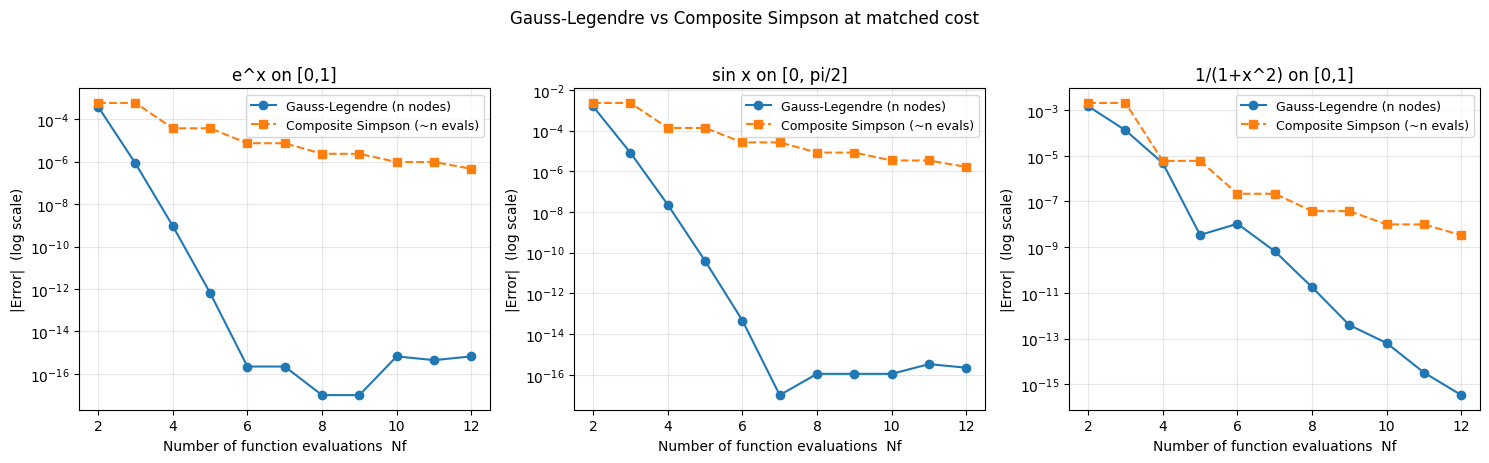

In [4]:
def simpson_integrate(f, n_intervals, a, b):
    h = (b - a) / n_intervals
    xs = np.linspace(a, b, n_intervals + 1)
    fx = f(xs)
    return (h / 3.0) * (fx[0] + fx[-1] + 4.0 * fx[1:-1:2].sum() + 2.0 * fx[2:-2:2].sum())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, (f, a, b, I)) in zip(axes, problems.items()):
    nfs, eg, es = [], [], []
    for n in range(2, 13):
        g_err = abs(gauss_integrate(f, n, a, b) - I)
        m = n if n % 2 == 0 else n - 1
        if m < 2: m = 2
        s_err = abs(simpson_integrate(f, m, a, b) - I)
        nfs.append(n); eg.append(max(g_err, 1e-17)); es.append(max(s_err, 1e-17))
    ax.semilogy(nfs, eg, "o-", label="Gauss-Legendre (n nodes)")
    ax.semilogy(nfs, es, "s--", label="Composite Simpson (~n evals)")
    ax.set_xlabel("Number of function evaluations  Nf")
    ax.set_ylabel("|Error|  (log scale)")
    ax.set_title(name)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=9)
fig.suptitle("Gauss-Legendre vs Composite Simpson at matched cost", y=1.02)
fig.tight_layout()
plt.show()


## 4. 결과 해석

1. **(Sanity)** Newton-on-Chebyshev-seed 으로 만든 노드/가중치는 NumPy 의 황금-표준 (`np.polynomial.legendre.leggauss`) 과 *모든 $n$ 에서 $\sim 10^{-15}$ 일치*. → 내 구현이 신뢰할 만하며, 이후 결과의 차이는 알고리즘의 본질 때문 (구현 버그가 아님).

2. **차수 정확성 표 (degree-of-exactness)** — *가장 중요한 그림*. 각 행 ($n$) 을 왼→오른쪽으로 보면, $k = 0, 1, \ldots, 2n - 1$ 까지는 *오차가 머신 epsilon 부근* ($\sim 10^{-16}$). 그러다 *정확히* $k = 2n$ 에서 **유한한 값** 으로 점프. 이 점프는 Gauss 의 *최적성* 의 직접 증거:
   - $n = 2$ → $k \leq 3$ 정확, $k = 4$ 에서 오차 출현,
   - $n = 5$ → $k \leq 9$ 정확, $k = 10$ 에서 오차 출현, …
   *어떤 다른 $n$-노드 공식도 $2n - 1$ 보다 높은 차수에 도달할 수 없다* — 자유도 셈으로 증명되는 한계.

3. **세 부드러운 적분의 절대오차표** — $n = 4$ 만 해도 $\sim 10^{-7}$, $n = 6$ 에서 $\sim 10^{-11}$, $n = 8$ 에서 머신 한계 $\sim 10^{-15}$. *지수적 수렴* 이 한 눈에. $1/(1 + x^2)$ 가 가장 느리지만 (특이점이 $\pm i$ 의 *복소* 평면에 있어 Bernstein 타원 반경이 작음), 그래도 $n = 8$ 에서 $\sim 10^{-13}$.

4. **Gauss vs Simpson @ 같은 비용 (그림)** — 가로축은 함수 평가 횟수 $N_f$. Simpson 은 $-4$ 의 일정 기울기 직선 (loglog), Gauss 는 *직선이 아니다* — *기울기 자체가 점점 가팔라진다*. 같은 $N_f = 8$ 에서 Gauss 가 Simpson 보다 *수 자릿수* 더 정확.

> **결론 (한 줄)**: **$n$ 개 함수 평가로 *$2n - 1$ 차 다항식 적분이 정확*** — 노드 자체를 자유롭게 두는 한 단계의 *대가* 가 차수의 *두 배 점프*. 부드러운 함수에서는 오차가 $n$ 의 *초선형* 함수.

다음 (Problem 2): 같은 정확도를 얻기 위한 *함수 평가 비용* 비교 — Trapezoid ($-2$), Simpson ($-4$), Romberg 대각, Gauss 네 가지를 *같은 그림* 에서 본다. break-even 지점과 *언제* Gauss 를 선택해야 하는지.
